# import libray , load, merge  & check data

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
fact = pd.read_csv("/content/fact_bitcoin_market.csv",low_memory=False)
dim_timeframe = pd.read_csv("/content/dim_timeframe.csv",low_memory=False)
dim_date = pd.read_csv("/content/dim_date.csv",low_memory=False)

In [ ]:
fact.head()

,date_key,timeframe_key,Open,High,Low,Close,Volume,capital_flow,trade_activity,price_change,...,volume_spike,high_volatility,high_volatility_length,compression,overheating,whale_activity,breakout_up,breakout_down,support,resistance
0,1,1,13774.99,13775.99,13600.00,13698.00,74.453320,1.019043e+06,1312,-76.99,...,0,1,2,0,0,0,0,0,98.00,77.99
1,2,1,13698.00,13775.00,13590.00,13644.95,89.776654,1.228408e+06,895,-53.05,...,0,1,3,0,0,0,0,0,54.95,130.05
2,3,1,13644.97,13659.97,13555.02,13570.35,43.920484,5.972011e+05,814,-74.62,...,0,0,1,0,0,0,0,0,15.33,89.62
3,4,1,13569.98,13665.00,13520.00,13656.23,58.542067,7.948098e+05,919,86.25,...,0,1,1,0,0,0,0,0,136.23,8.77
4,5,1,13656.23,13735.24,13610.27,13632.89,58.900513,8.054309e+05,869,-23.34,...,0,0,1,0,0,0,0,0,22.62,102.35


In [ ]:
dim_date.head()

,date_key,Open time,year,timeframe,quarter,month,day
0,1,2018-01-01 07:15:00+00:00,2018,15m,1,1,1
1,2,2018-01-01 07:30:00+00:00,2018,15m,1,1,1
2,3,2018-01-01 07:45:00+00:00,2018,15m,1,1,1
3,4,2018-01-01 08:00:00+00:00,2018,15m,1,1,1
4,5,2018-01-01 08:15:00+00:00,2018,15m,1,1,1


In [ ]:
dim_timeframe.head()

,timeframe_key,timeframe
0,1,15m
1,2,1h
2,3,4h
3,4,1d


In [ ]:
dim_date["Open time"] = pd.to_datetime(dim_date["Open time"])

In [ ]:
fact.info()
dim_date.info()
dim_timeframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391385 entries, 0 to 391384
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date_key                391385 non-null  int64  
 1   timeframe_key           391385 non-null  int64  
 2   Open                    391385 non-null  float64
 3   High                    391385 non-null  float64
 4   Low                     391385 non-null  float64
 5   Close                   391385 non-null  float64
 6   Volume                  391385 non-null  float64
 7   capital_flow            391385 non-null  float64
 8   trade_activity          391385 non-null  int64  
 9   price_change            391385 non-null  float64
 10  return_pct              391385 non-null  float64
 11  volatility              391385 non-null  float64
 12  buy_volume              391385 non-null  float64
 13  sell_volume             391385 non-null  float64
 14  buy_ratio           

In [ ]:
print(fact.shape)
print(dim_date.shape)
print(dim_timeframe.shape)

(391385, 32)
(391385, 7)
(4, 2)


In [ ]:
rows_before = len(fact)

df = fact.merge(dim_date, on="date_key", how="left")
assert len(df) == rows_before, "dim_date merge changed row count - duplication bug!"

In [ ]:
dim_timeframe_extra = dim_timeframe.drop(columns=["timeframe"])
df = df.merge(dim_timeframe_extra, on="timeframe_key", how="left")
assert len(df) == rows_before, "dim_timeframe merge changed row count - duplication bug!"
print("Row count stable after merges:", len(df), "(expected:", rows_before, ")")
print("Shape:", df.shape)
df.info()
df.describe()

Row count stable after merges: 391385 (expected: 391385 )
Shape: (391385, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391385 entries, 0 to 391384
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   date_key                391385 non-null  int64              
 1   timeframe_key           391385 non-null  int64              
 2   Open                    391385 non-null  float64            
 3   High                    391385 non-null  float64            
 4   Low                     391385 non-null  float64            
 5   Close                   391385 non-null  float64            
 6   Volume                  391385 non-null  float64            
 7   capital_flow            391385 non-null  float64            
 8   trade_activity          391385 non-null  int64              
 9   price_change            391385 non-null  float64            
 10  return_pct    

,date_key,timeframe_key,Open,High,Low,Close,Volume,capital_flow,trade_activity,price_change,...,overheating,whale_activity,breakout_up,breakout_down,support,resistance,year,quarter,month,day
count,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,3.913850e+05,3.913850e+05,391385.000000,...,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.00000,391385.000000
mean,195693.000000,1.306862,39333.158370,39440.500293,39221.160604,39333.803455,1967.862692,5.651153e+07,6.305021e+04,0.645085,...,0.014822,0.009584,0.039570,0.035045,112.642851,106.696838,2021.748112,2.453175,6.35219,15.691511
std,112983.261891,0.595019,32557.861859,32624.286368,32489.537836,32558.025841,9628.280507,2.517477e+08,2.731712e+05,237.837448,...,0.120839,0.097427,0.194946,0.183893,224.266704,209.250489,2.447237,1.117984,3.45284,8.798631
min,1.000000,1.000000,3166.110000,3174.780000,3156.260000,3167.070000,0.000000,0.000000e+00,0.000000e+00,-8049.380000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000,1.000000,1.00000,1.000000
25%,97847.000000,1.000000,9694.630000,9726.740000,9660.740000,9694.650000,220.138490,4.994906e+06,6.178000e+03,-39.040000,...,0.000000,0.000000,0.000000,0.000000,14.310000,12.970000,2020.000000,1.000000,3.00000,8.000000
50%,195693.000000,1.000000,29325.900000,29379.830000,29276.880000,29326.690000,469.253358,1.402873e+07,1.555700e+04,0.310000,...,0.000000,0.000000,0.000000,0.000000,43.890000,40.860000,2022.000000,2.000000,6.00000,16.000000
75%,293539.000000,1.000000,62212.790000,62405.300000,62037.800000,62213.840000,1261.560966,3.799360e+07,4.372500e+04,40.800000,...,0.000000,0.000000,0.000000,0.000000,124.860000,118.810000,2024.000000,3.000000,9.00000,23.000000
max,391385.000000,4.000000,126011.180000,126199.630000,125648.010000,126011.180000,760705.362783,1.746531e+10,1.522359e+07,8277.980000,...,1.000000,1.000000,1.000000,1.000000,11451.860000,8368.690000,2026.000000,4.000000,12.00000,31.000000


In [ ]:
df = df.sort_values("Open time")
df = df.reset_index(drop=True)

In [ ]:
df.columns.tolist()

['date_key',
 'timeframe_key',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'capital_flow',
 'trade_activity',
 'price_change',
 'return_pct',
 'volatility',
 'buy_volume',
 'sell_volume',
 'buy_ratio',
 'sell_ratio',
 'order_flow',
 'trend_direction',
 'trend_length',
 'trend_strength',
 'avg_volume_20',
 'avg_volatility_20',
 'volume_spike',
 'high_volatility',
 'high_volatility_length',
 'compression',
 'overheating',
 'whale_activity',
 'breakout_up',
 'breakout_down',
 'support',
 'resistance',
 'Open time',
 'year',
 'timeframe',
 'quarter',
 'month',
 'day']

# FILTER

In [ ]:
# ==========================================
# EDA Filters
# Change these values to analyze different data
# ==========================================

selected_year = None        # Example: 2024
selected_quarter = None       # Example: 1, 2, 3, 4
selected_month = None       # Example: 1 to 12
selected_day = None           # Example: 15
selected_timeframe = None     # Example: "1d", "4h", "15m","1h"

# Create a copy of the original dataset
df_filtered = df.copy()

# Apply filters
if selected_year is not None:
    df_filtered = df_filtered[df_filtered["year"] == selected_year]

if selected_quarter is not None:
    df_filtered = df_filtered[df_filtered["quarter"] == selected_quarter]

if selected_month is not None:
    df_filtered = df_filtered[df_filtered["month"] == selected_month]

if selected_day is not None:
    df_filtered = df_filtered[df_filtered["day"] == selected_day]

if selected_timeframe is not None:
    df_filtered = df_filtered[df_filtered["timeframe"] == selected_timeframe]

# Display current filters
print("========== EDA FILTERS ==========")
print(f"Year      : {selected_year}")
print(f"Quarter   : {selected_quarter}")
print(f"Month     : {selected_month}")
print(f"Day       : {selected_day}")
print(f"Timeframe : {selected_timeframe}")
print(f"Rows after filtering: {len(df_filtered):,}")

========== EDA FILTERS ==========
Year      : None
Quarter   : None
Month     : None
Day       : None
Timeframe : None
Rows after filtering: 391,385


# EDA

Explore price change and volatility across different timeframes to identify variability and detect potential outliers.

**Insight (Full dataset - No filters applied)**

---


Price change and volatility span a wide range, reaching approximately ±8,000 for price change and up to 15,000 for volatility. Given the dataset covers the Bitcoin market from 2018 onward, these extreme values likely represent major market events such as strong rallies, crashes, or periods of exceptionally high volatility rather than data errors.

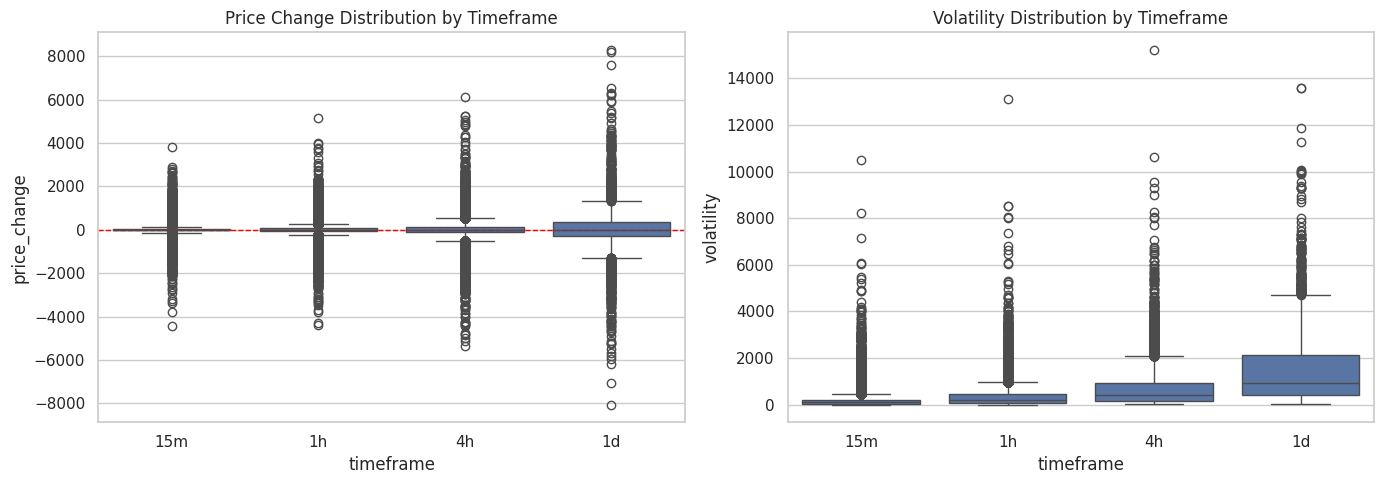

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_filtered, x="timeframe", y="price_change", ax=axes[0])
axes[0].set_title("Price Change Distribution by Timeframe")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)

sns.boxplot(data=df_filtered, x="timeframe", y="volatility", ax=axes[1])
axes[1].set_title("Volatility Distribution by Timeframe")

plt.tight_layout()
plt.show()

 Explore trend length distribution across different timeframes to understand how long market trends typically persist.


**Insight (Full dataset - No filters applied)**

---


Most market trends remain short-lived, with the majority lasting only 1–2 consecutive candles(row). Trends extending beyond 5–6 candles are relatively rare, indicating that prolonged directional movements are uncommon even across the full historical dataset.

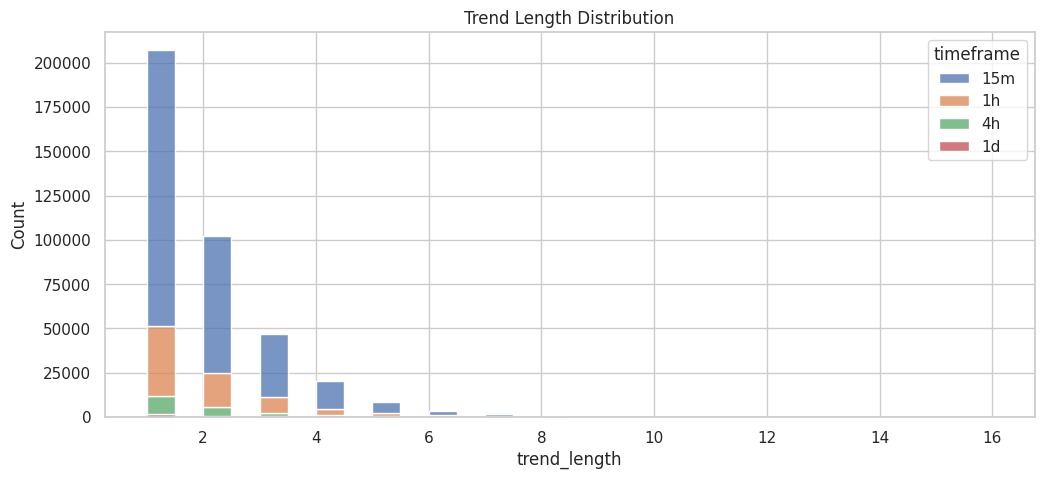

In [ ]:


plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_filtered,
    x="trend_length",
    hue="timeframe",
    bins=30,
    multiple="stack"
)

plt.title("Trend Length Distribution")

plt.show()

 Explore buy ratio distribution across different timeframes to evaluate buyer dominance and buying pressure.

 **Insight (Full dataset - No filters applied)**

---

 The buy ratio remains strongly centered around 50% across the entire dataset, indicating that the market is generally balanced. Buyer or seller dominance occurs only during specific periods rather than representing the market's normal state.

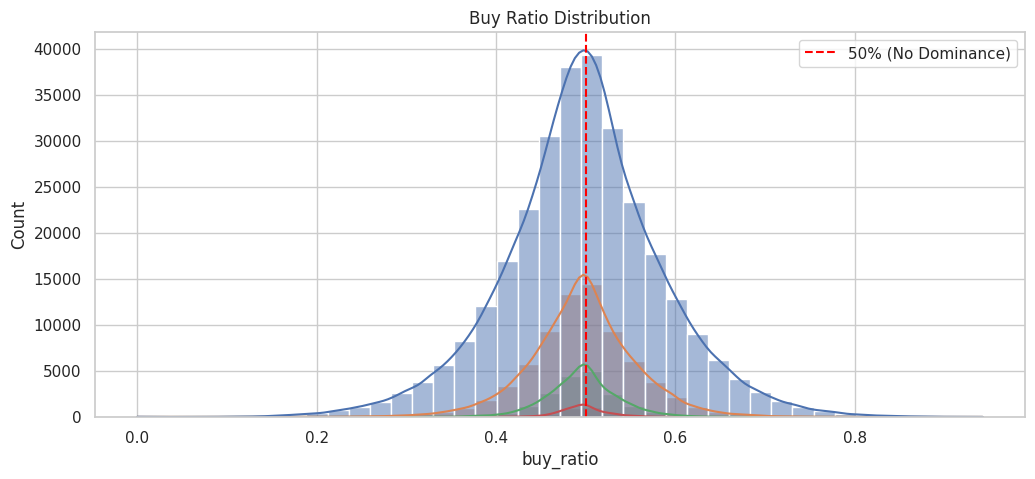

In [ ]:

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_filtered,
    x="buy_ratio",
    hue="timeframe",
    bins=40,
    kde=True
)

plt.axvline(0.5, color="red", linestyle="--", label="50% (No Dominance)")

plt.title("Buy Ratio Distribution")

plt.legend()

plt.show()

 Explore trade activity across different timeframesto compare market participation and trading intensity.

**Insight (Full dataset - No filters applied)**

---

An extreme outlier of approximately 1.5 million trades appears in the daily timeframe, suggesting an exceptional trading day with unusually high market participation. This event is worth investigating further by identifying its exact date.

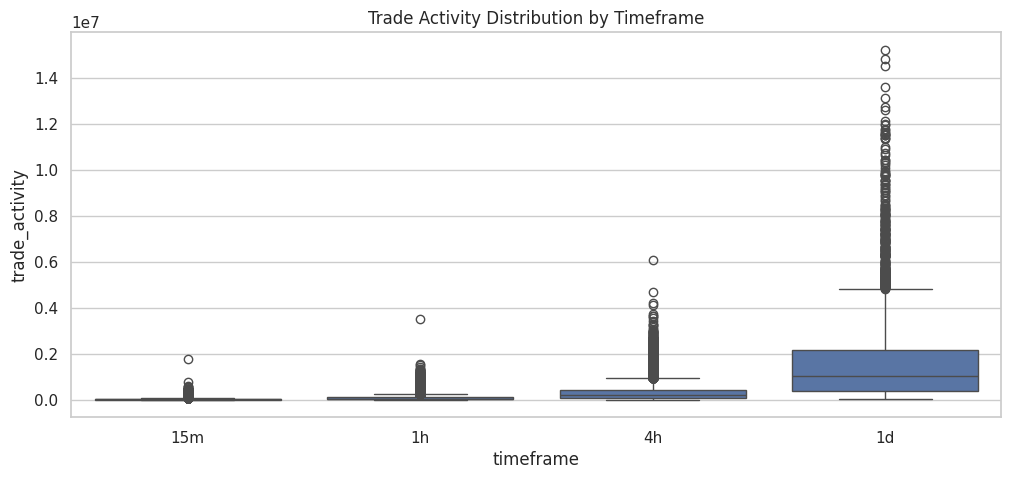

In [ ]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df_filtered,
    x="timeframe",
    y="trade_activity"
)

plt.title("Trade Activity Distribution by Timeframe")

plt.show()

In [ ]:
outlier_day = df_filtered[df_filtered["timeframe"] == "1d" ].sort_values(
    "trade_activity", ascending=False
).head(2)

print(outlier_day[["Open time", "trade_activity", "price_change", "volatility", "Volume"]])

                       Open time  trade_activity  price_change  volatility  \
240266 2023-03-14 00:00:00+00:00        15223589        558.14     2410.45   
240140 2023-03-13 00:00:00+00:00        14820760       2115.43     2686.12   

              Volume  
240266  699360.93423  
240140  687889.31259  


**bold text** Explore average volatility over time to observe long-term changes in market volatility.

**Insight (Full dataset - No filters applied)**

---
Average volatility exhibits clear cyclical behavior rather than remaining constant over time. Major volatility peaks are observed around 2021 and 2025, while the period between 2018 and 2020 appears relatively stable. This indicates that the Bitcoin market alternates between periods of low and high volatility over its market cycles.

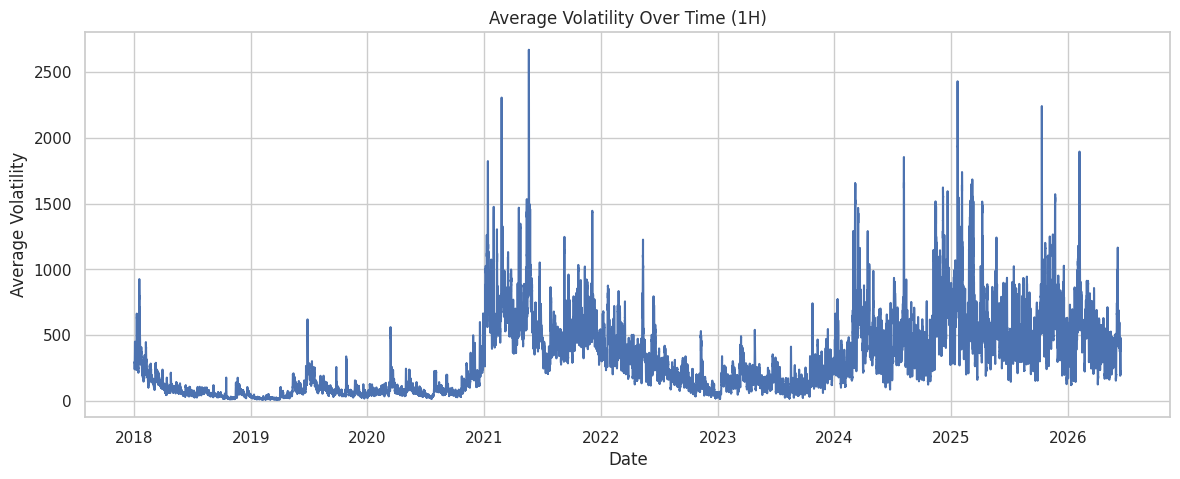

In [ ]:
sample_tf = (
    df_filtered[df_filtered["timeframe"] == "1h"]
    .sort_values("Open time")
)

plt.figure(figsize=(14, 5))

plt.plot(
    sample_tf["Open time"],
    sample_tf["avg_volatility_20"]
)

plt.title("Average Volatility Over Time (1H)")
plt.xlabel("Date")
plt.ylabel("Average Volatility")

plt.show()

 Explore correlations between key market variables to understand relationships between price movement, volume, and volatility.

**Insight (Full dataset - No filters applied)**


---


The correlation analysis reveals that volume-related variables (Volume, buy_volume, and sell_volume) are perfectly correlated (1.00), which is expected since they are mathematically dependent components of total volume rather than independent signals.
Interestingly, price_change shows almost no meaningful correlation with other variables, indicating that short-term price movements are largely independent of trading volume and activity intensity in this dataset.
A strong positive relationship is observed between trade_activity, capital_flow, and Volume (0.79–0.90), suggesting that these variables collectively represent overall market activity from different perspectives.
Volatility shows a moderate correlation with trade_activity and capital_flow (0.55–0.58), indicating that higher activity levels are generally associated with increased market fluctuations, but the relationship is not strongly linear.



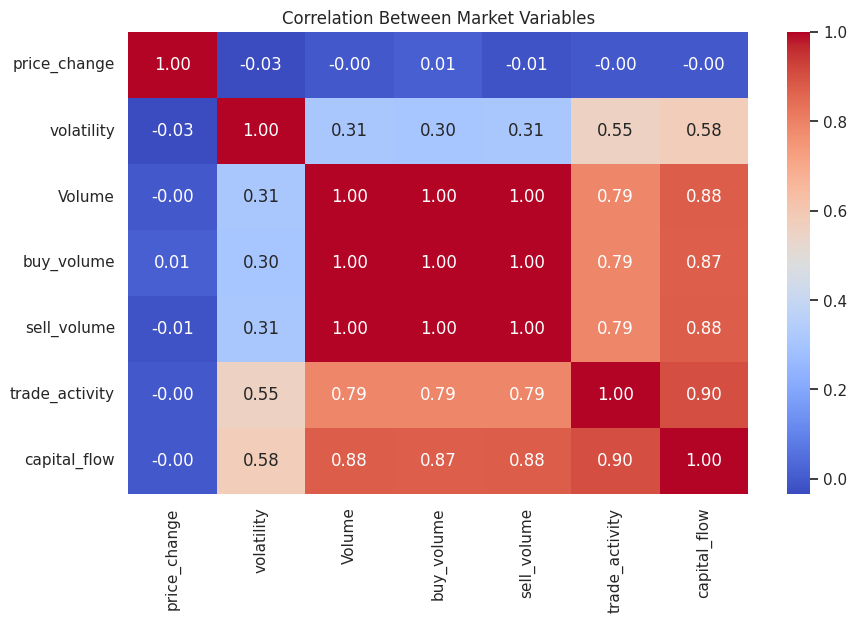

In [ ]:
corr_cols = [
    "price_change",
    "volatility",
    "Volume",
    "buy_volume",
    "sell_volume",
    "trade_activity",
    "capital_flow"
]

corr = df_filtered[corr_cols].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Market Variables")

plt.show()

# Dashboards

## Markert Behavier Analysis dashboard

This chart shows the overall price movement within each time interval by measuring the difference between Open and Close prices.
It helps identify whether the market is in a bullish or bearish state over time and highlights short-term directional trends.

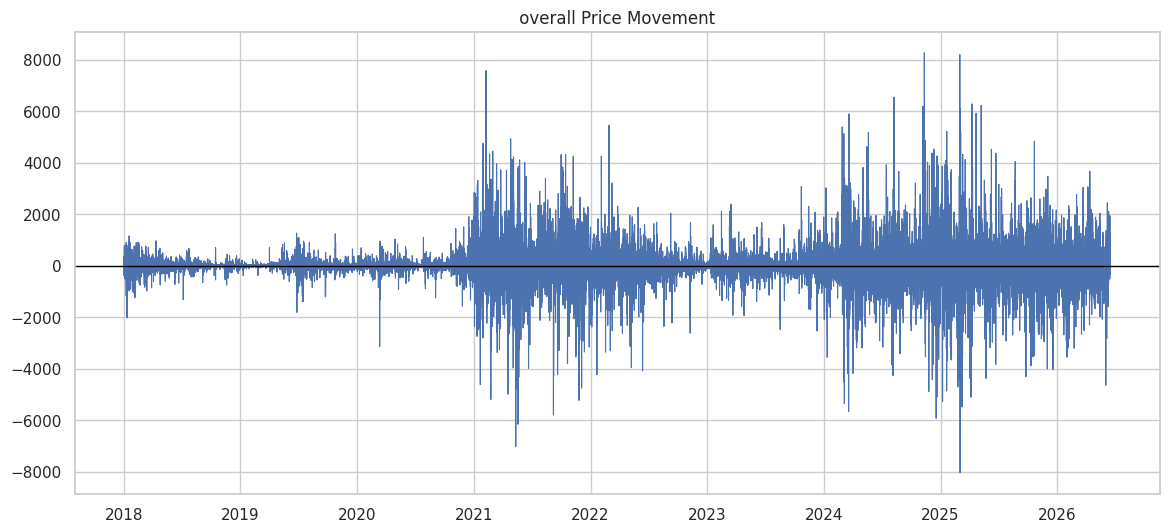

In [ ]:
# Overall price movment
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["price_change"], linewidth=0.8)

plt.title(" overall Price Movement ")

plt.axhline(0, color="black", linewidth=1)

plt.show()

This chart measures market volatility by calculating the difference between the High and Low prices in each interval.
Higher values indicate stronger price fluctuations and increased market risk, while lower values suggest more stable market conditions.



Volatility spikes indicate periods of intense price fluctuations and increased market uncertainty. These periods may represent higher trading opportunities but also higher risk.

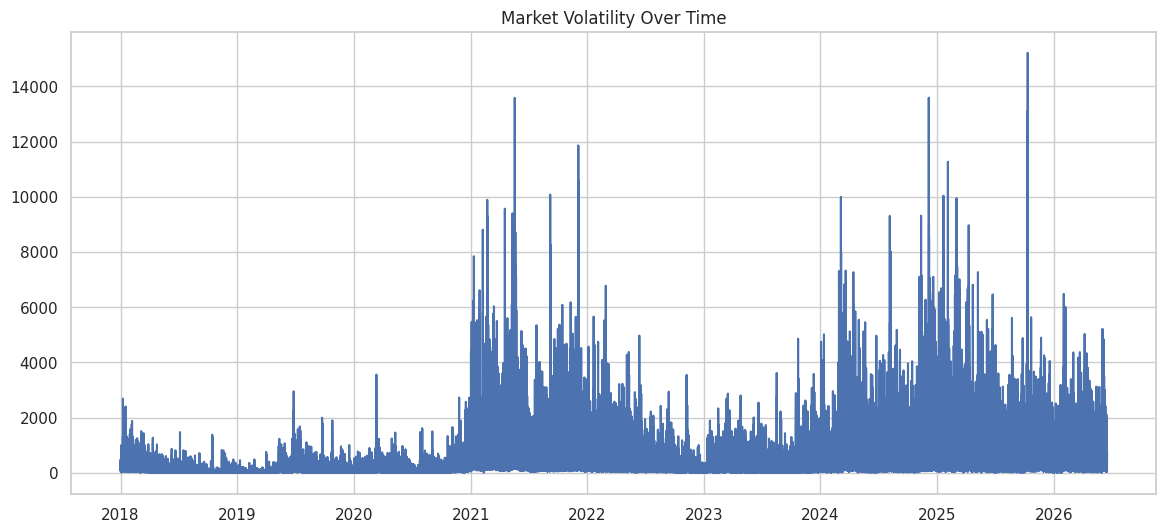

In [ ]:
# How volatile the market within each intervall?

plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["volatility"])

plt.title("Market Volatility Over Time")


plt.show()

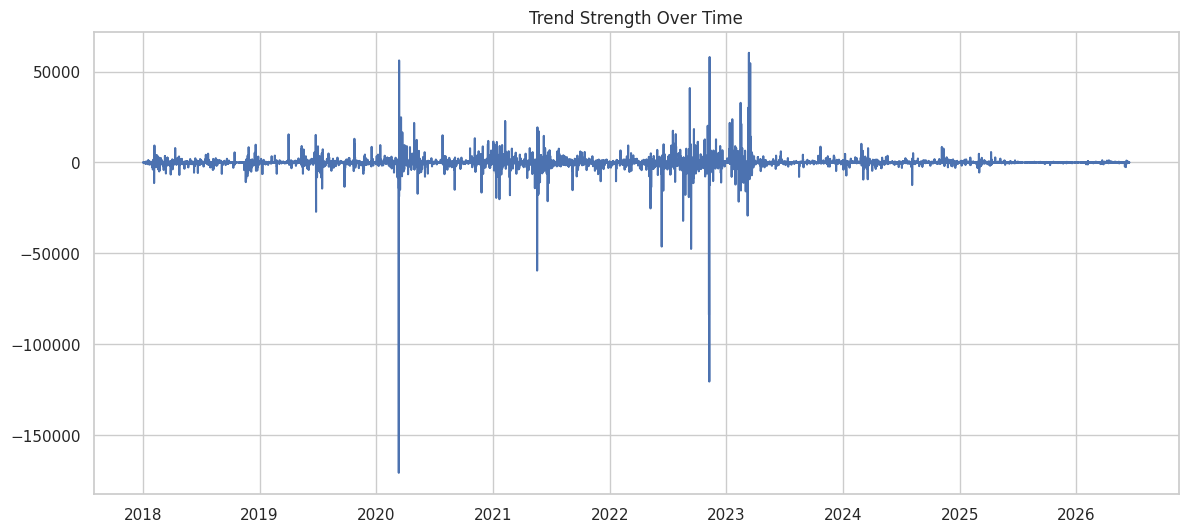

In [ ]:
# how strong is the market trend?
plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["trend_strength"])

plt.title("Trend Strength Over Time")

plt.show()


This chart shows how long market trends persist before reversing.
Short trend lengths indicate frequent direction changes, while longer trend lengths suggest stronger and more sustained market trends.

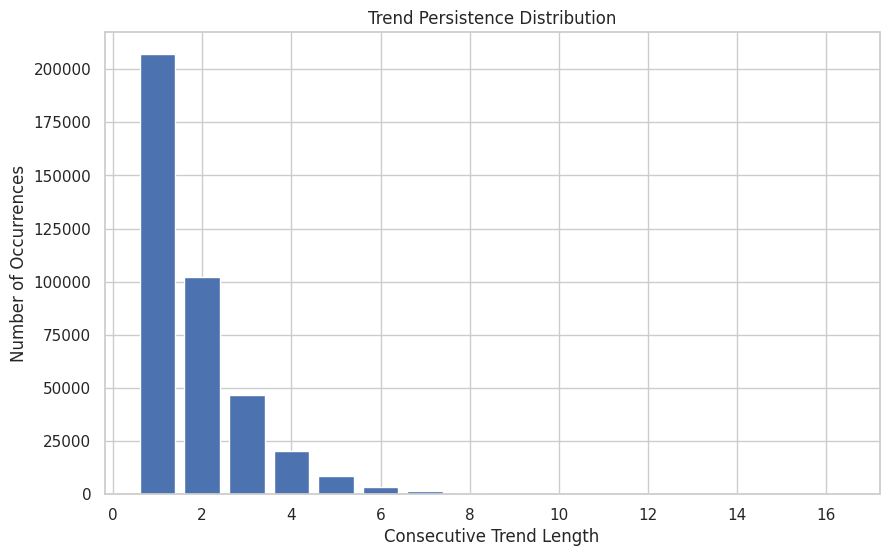

In [ ]:
#Trend Persistence Distribution
trend_counts = df_filtered["trend_length"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(trend_counts.index, trend_counts.values)

plt.title("Trend Persistence Distribution")
plt.xlabel("Consecutive Trend Length")
plt.ylabel("Number of Occurrences")

plt.show()

## market participation dashboard

This chart displays trading volume over time.
Volume spikes indicate periods of unusually high market participation, which may precede significant price movements.

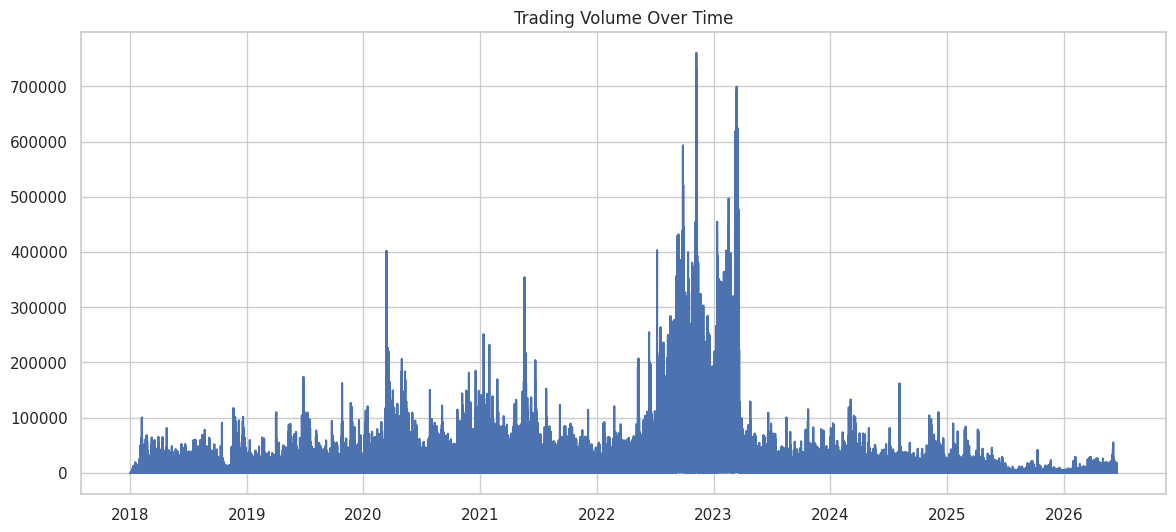

In [ ]:
# When does trading activity spike?

plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["Volume"])

plt.title("Trading Volume Over Time")

plt.show()

This chart measures the number of trades executed over time, representing the level of trader participation in the market.
It highlights periods of increased or decreased trading activity, regardless of the total trading volume.
Higher values indicate greater market participation and more intense trading activity, suggesting stronger engagement from market participants.

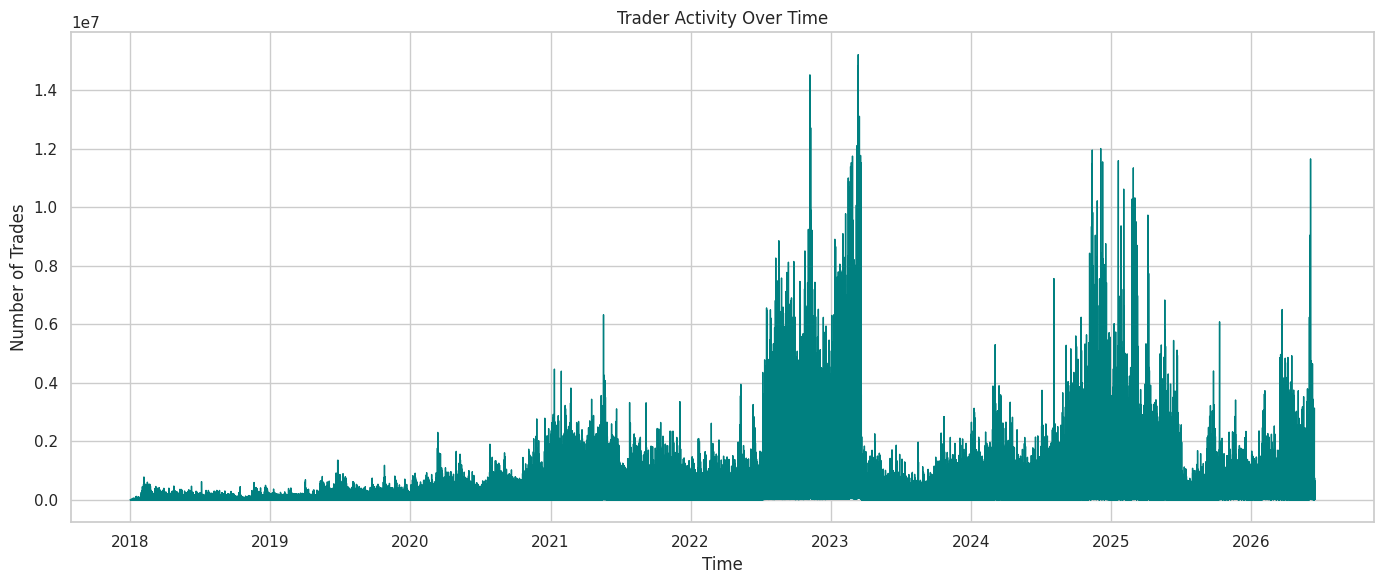

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df_filtered["Open time"],
    df_filtered["trade_activity"],
    color="teal",
    linewidth=1
)

plt.title("Trader Activity Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.show()

This chart compares buyer and seller dominance over time.
Higher buy ratios indicate stronger buying pressure, while higher sell ratios suggest increased selling activity.

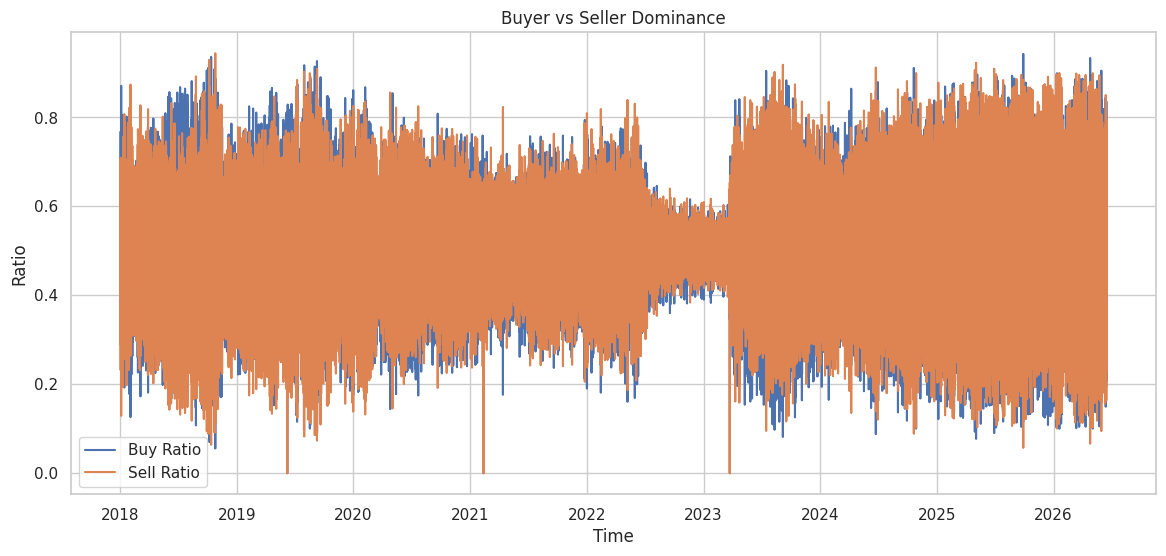

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["buy_ratio"], label="Buy Ratio")
plt.plot(df_filtered["Open time"],df_filtered["sell_ratio"], label="Sell Ratio")

plt.title("Buyer vs Seller Dominance")
plt.xlabel("Time")
plt.ylabel("Ratio")

plt.legend()

plt.show()

This chart measures the net order flow by comparing buying and selling activity over time.
Positive values indicate stronger buying pressure, while negative values indicate stronger selling pressure. Significant deviations from zero may signal potential short-term market direction changes.

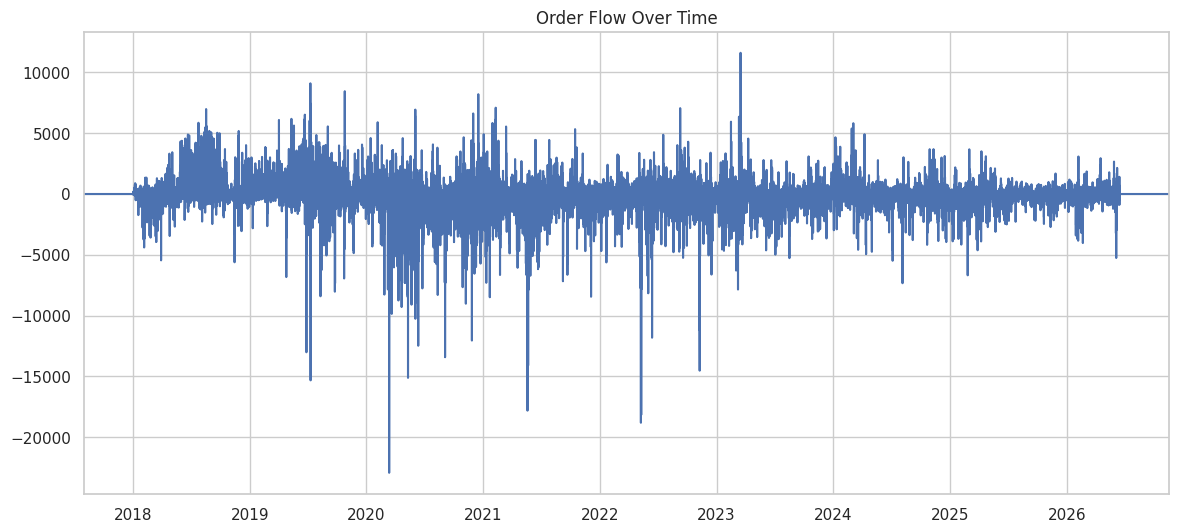

In [ ]:
# Order flow  over time

plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["order_flow"])

plt.axhline(y=0)

plt.title("Order Flow Over Time")


plt.show()

This chart shows the total capital flowing through the Bitcoin market each year.
Higher values indicate increased market liquidity and participation, while lower values suggest reduced trading activity.

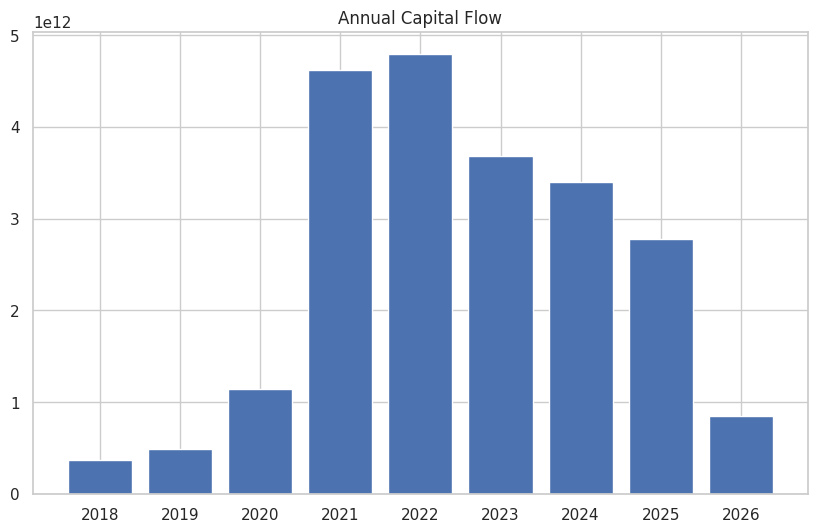

In [ ]:
# Annual Capital Flow

capital_by_year = (
    df_filtered.groupby("year")["capital_flow"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,6))
plt.bar(capital_by_year.index.astype(str), capital_by_year.values)

plt.title("Annual Capital Flow")


plt.show()

## Market Risk dashboard

This chart shows how frequently the market entered an overheated state each year. An overheated market is identified when buying pressure, trading volume, and positive returns occur simultaneously, indicating periods of unusually strong bullish momentum..

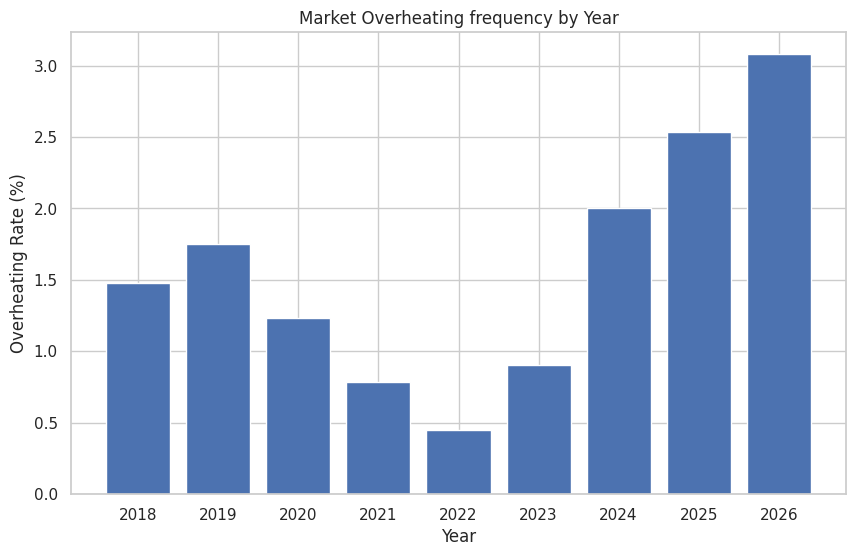

In [ ]:
# What percentage of time was the market overheated each year?

overheating_rate = (
    df_filtered.groupby("year")["overheating"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10,6))

plt.bar(
    overheating_rate.index.astype(str),
    overheating_rate.values
)

plt.title("Market Overheating frequency by Year")
plt.xlabel("Year")
plt.ylabel("Overheating Rate (%)")

plt.show()



TThis chart shows how frequently whale-like trading activity occurred each year. Whale activity is identified when unusually high trading volume is accompanied by fewer-than-average trades, indicating potential large transactions from institutional or high-volume participants.

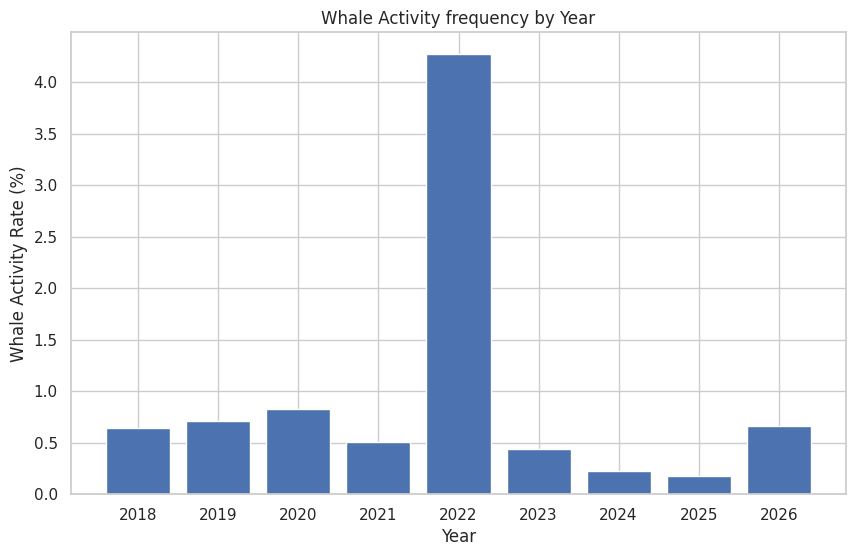

In [ ]:
# What percentage of time were whales active each year?

whale_activity_rate = (
    df_filtered.groupby("year")["whale_activity"]
    .mean()
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    whale_activity_rate.index.astype(str),
    whale_activity_rate.values
)

plt.title("Whale Activity frequency by Year")
plt.xlabel("Year")
plt.ylabel("Whale Activity Rate (%)")

plt.show()

This chart measures how often market volatility exceeded its recent 20-period
average.

It highlights periods of above-normal volatility rather than only extreme volatility events.
Higher values indicate that the market spent a larger portion of the year trading above its recent average volatility, suggesting more frequent periods of above-normal price fluctuations.

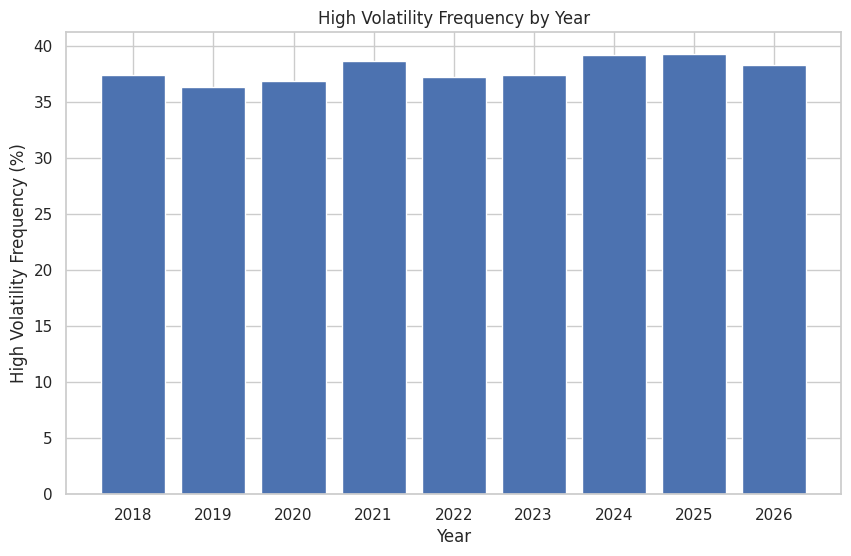

In [ ]:
# How frequently did high-volatility periods occur each year?

high_volatility_rate = (
    df_filtered.groupby("year")["high_volatility"]
    .mean()
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    high_volatility_rate.index.astype(str),
    high_volatility_rate.values
)

plt.title("High Volatility Frequency by Year")
plt.xlabel("Year")
plt.ylabel("High Volatility Frequency (%)")

plt.show()

This chart compares the number of bullish and bearish breakout events each year. A breakout is recorded when the price moves beyond its recent trading range with above-average trading volume, indicating a potentially significant market move.

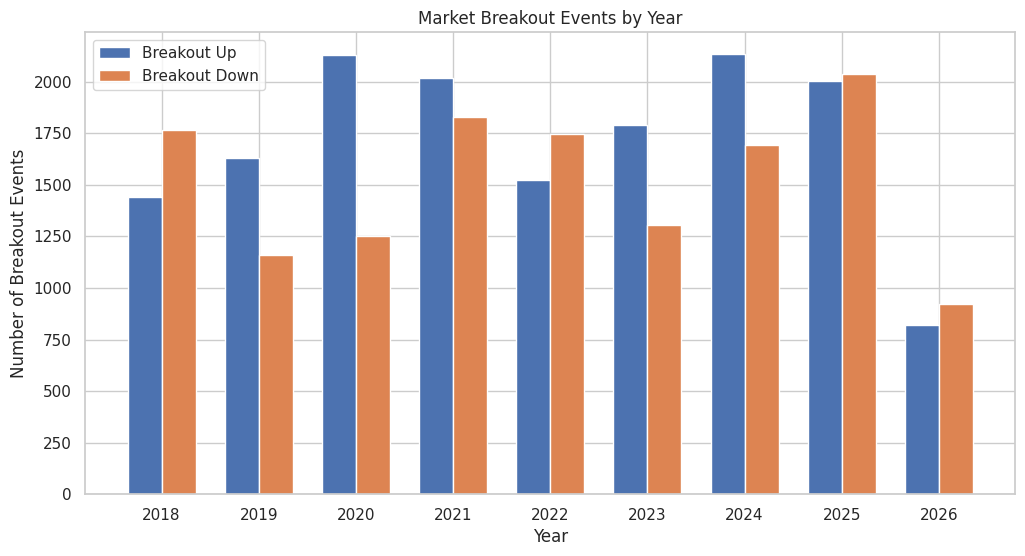

In [ ]:
# Market Breakout Events by Year

breakout_by_year = (
    df_filtered
    .groupby("year")[["breakout_up", "breakout_down"]]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12,6))

x = range(len(breakout_by_year))

width = 0.35

plt.bar(
    [i - width/2 for i in x],
    breakout_by_year["breakout_up"],
    width=width,
    label="Breakout Up"
)

plt.bar(
    [i + width/2 for i in x],
    breakout_by_year["breakout_down"],
    width=width,
    label="Breakout Down"
)

plt.xticks(x, breakout_by_year.index.astype(str))

plt.title("Market Breakout Events by Year")
plt.xlabel("Year")
plt.ylabel("Number of Breakout Events")

plt.legend()

plt.show()

## Support & market structure dashboard

This chart measures how often the market experienced strong price rejection at the highs, calculated using the difference between High and Close prices.
It highlights periods where buyers attempted to push prices higher, but sellers forced the price back down before closing.
Higher values indicate stronger selling pressure and more frequent rejection from upper price levels, suggesting that the market struggled to continue upward during those periods.

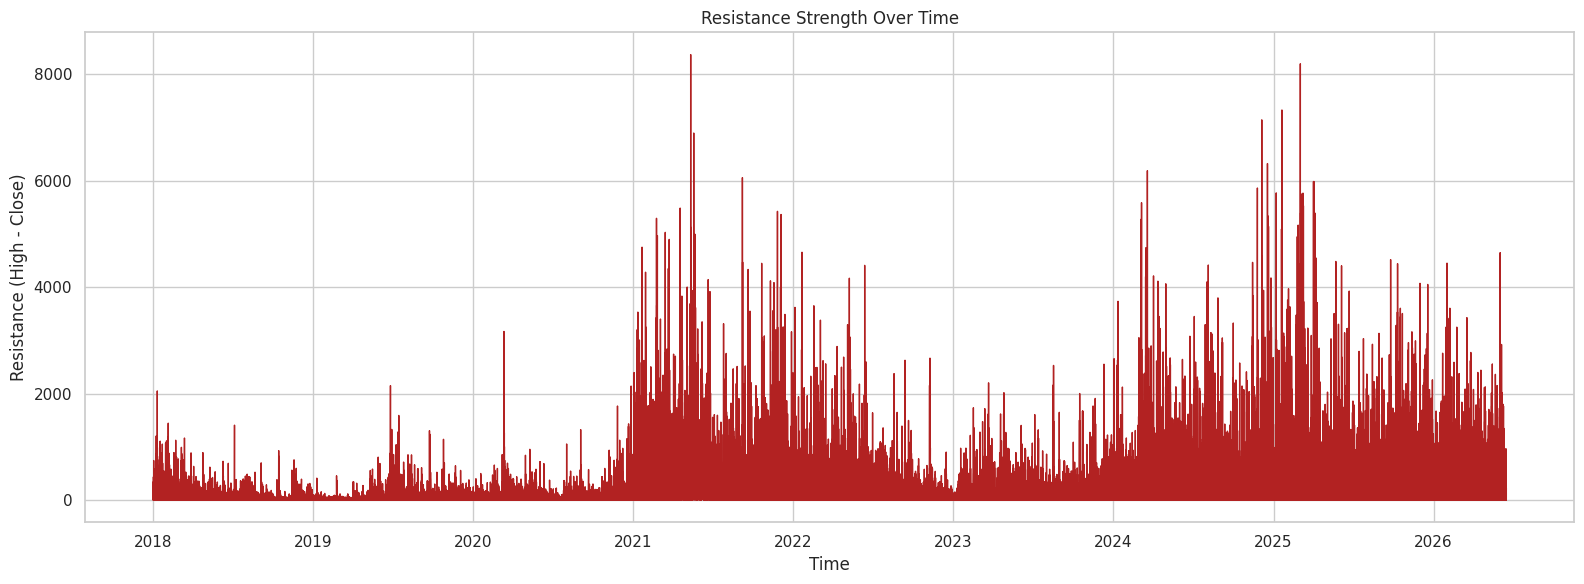

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    df_filtered["Open time"],
    df_filtered["resistance"],
    color="firebrick",
    linewidth=1
)

plt.title("Resistance Strength Over Time")
plt.xlabel("Time")
plt.ylabel("Resistance (High - Close)")

plt.tight_layout()
plt.show()

This chart measures how often the market experienced price rejection at the lows, calculated using the difference between Close and Low prices.
It highlights periods where prices dropped but were pushed back up before closing.
Higher values indicate stronger buying pressure and frequent defense of lower price levels, suggesting that the market was well-supported during those periods.

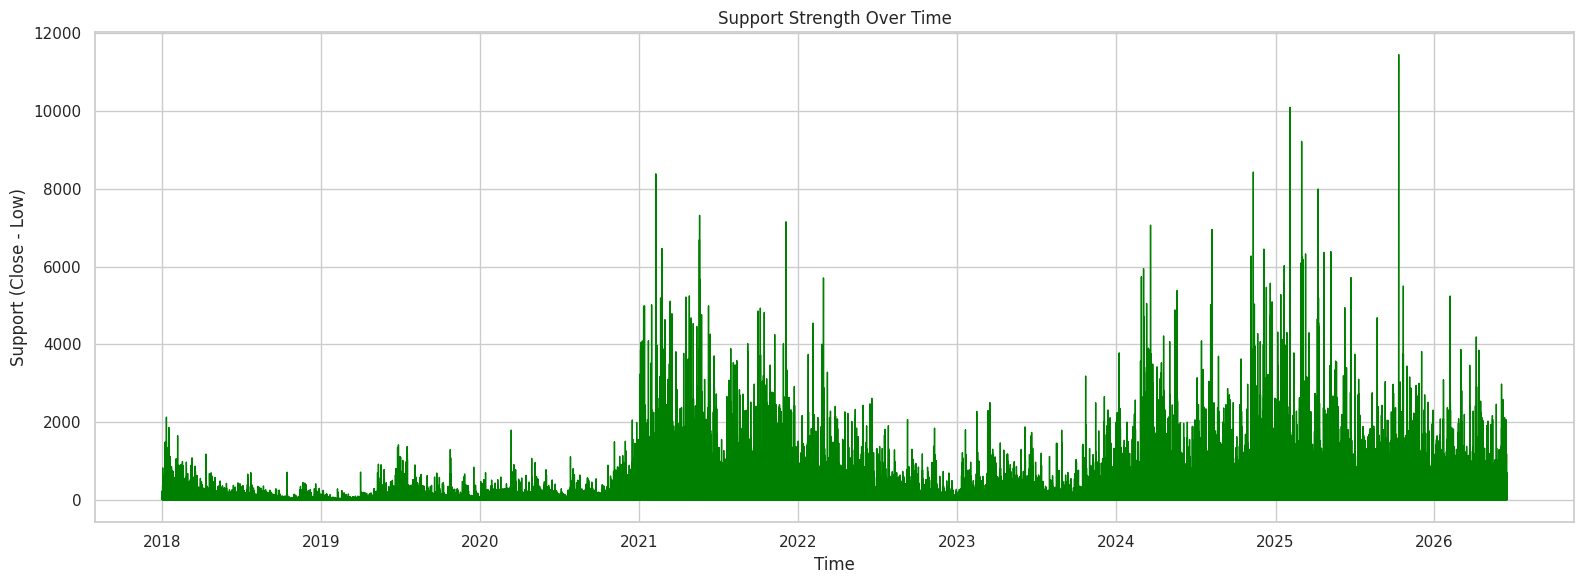

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    df_filtered["Open time"],
    df_filtered["support"],
    color="green",
    linewidth=1
)

plt.title("Support Strength Over Time")
plt.xlabel("Time")
plt.ylabel("Support (Close - Low)")

plt.tight_layout()
plt.show()

This chart measures periods where the market consistently experiences low volatility and low trading volume conditions.
It highlights phases of market consolidation, where price movement becomes narrow and directional momentum decreases.
Higher values indicate stronger and more sustained compression behavior, suggesting that the market is entering a low-activity phase that may precede significant price movements.

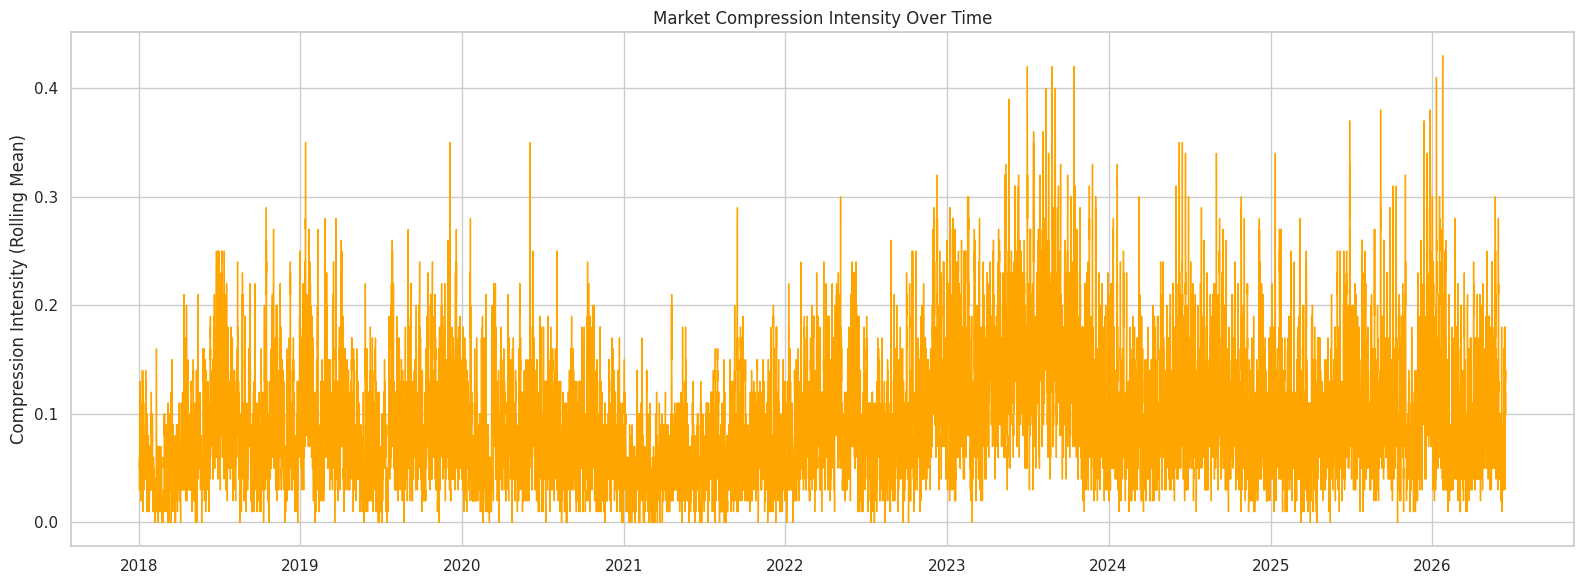

In [ ]:
df_filtered["compression_smooth"] =df_filtered["compression"].rolling(100).mean()

plt.figure(figsize=(16,6))

plt.plot(
    df_filtered["Open time"],
    df_filtered["compression_smooth"],
    color="orange",
    linewidth=1
)

plt.title("Market Compression Intensity Over Time")

plt.ylabel("Compression Intensity (Rolling Mean)")

plt.tight_layout()
plt.show()